# General Task Performance 

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [42]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS, baselines
from monoculture.analysis.metrics import (
    pairwise_agreement_at_random,
    matrix_pairwise_evals,
    pairwise_agreement_at_random,
)

from monoculture.analysis.utils import (
    key_to_model,
    prettify_model_name,
    get_size,
    get_size_and_it,
    is_instruction_tuned,
    load_model_outputs_same_prompt,
    get_metric,
    load_task_data,
)
from monoculture.baseline.utils import load_baselines

from monoculture.analysis.plotting import (
    plot_accuracies,
    plot_label_dist,
    plot_neg_predicted,
)

In [43]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures" / "same-prompt"
FIGURES_PAPER_DIR = RESULTS_ROOT_DIR / "figures/paper/same-prompt/"

tasks ('ACSIncome', 'ACSEmployment', 'ACSMobility', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


In [ ]:
data_all = None

## Load Task Data

In [67]:
data_dir = Path("./data")
if not data_all:
    data_all = load_task_data(TASKS, data_dir)
elif not all([t in data.keys()for t in TASKS]):
    for t in TASKS:
        if t not in data.keys():
            print(f'add {t} to data')
            data_t =load_task_data(t, Path("./data"))
            data_all.update(data_t)
            data = data_all.copy()


## Load predictions

In [68]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_same_prompt.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.776744,0.680409,3019759728,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.904552,0.727768,3118177042,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,0.438475,0.510381,3621160589,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,0.867235,0.659718,1712994131,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [69]:
print(df_same_prompt.shape)
try:
    assert set(TASKS).issubset(
        set(df_same_prompt["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_same_prompt['task'].unique())} "
except AssertionError:
    logging.warning("Reduced TASKS to available tasks.")
    TASKS = list(set(df_same_prompt["task"].unique()).intersection(TASKS))
TASKS

(340, 14)


('ACSIncome',
 'ACSEmployment',
 'ACSMobility',
 'ACSTravelTime',
 'ACSPublicCoverage',
 'BRFSS_Diabetes',
 'BRFSS_Blood_Pressure')

In [70]:
risk_scores = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=True
)
predictions_all = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_same_prompt[metric] = (
        df_same_prompt["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task_all = {}  # [task][metric][model]
for task in TASKS:
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task_all[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

ACSIncome
['meta-llama--Meta-Llama-3.2-1B-Instruct', 'allenai--OLMo-2-1124-7B-Instruct', 'google--gemma-2-27b', 'google--gemma-2-27b-it', 'meta-llama--Meta-Llama-3-70B', 'mistralai--Mistral-Small-24B-Base-2501', 'Qwen--Qwen2.5-72B-Instruct', 'meta-llama--Meta-Llama-3-8B', 'meta-llama--Meta-Llama-3.1-70B-Instruct', 'google--gemma-2-9b', 'allenai--OLMo-2-1124-7B', 'meta-llama--Meta-Llama-3-8B-Instruct', 'Qwen--Qwen2-72B-Instruct', 'meta-llama--Meta-Llama-3.2-3B', 'mistralai--Mistral-7B-v0.1', 'gpt-3.5-turbo-0125', 'meta-llama--Meta-Llama-3.1-8B', 'Qwen--Qwen2.5-7B-Instruct', 'Qwen--Qwen2-7B-Instruct', 'mistralai--Mistral-7B-Instruct-v0.2', 'Qwen--Qwen2-7B', 'google--gemma-2b', 'meta-llama--Meta-Llama-3.1-70B', '01-ai--Yi-6B', 'mistralai--Mixtral-8x22B-v0.1', 'mistralai--Mixtral-8x7B-v0.1', 'allenai--OLMo-7B-hf', 'meta-llama--Meta-Llama-3.2-3B-Instruct', 'meta-llama--Meta-Llama-3-70B-Instruct', '01-ai--Yi-6B-Chat', 'allenai--OLMo-7B-0724-hf', '01-ai--Yi-34B', 'allenai--OLMo-1B-hf', 'Qwen-

/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_50513/1532195901.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_50513/1532195901.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_50513/1532195901.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

## Load Baselines

In [71]:
baseline_scores, baseline_evals = load_baselines(baselines=baselines, tasks=TASKS)

logging.warning("Manually changed values.")
baseline_evals["BRFSS_Diabetes"]["XGBoost"] = {"accuracy": 0.0}
baseline_evals["BRFSS_Blood_Pressure"]["XGBoost"] = {"accuracy": 0.0}

baseline_predictions = {
    task: baseline_scores[task].map(lambda x: int(x >= 0.5)) for task in TASKS
}
baseline_predictions["ACSIncome"].head()

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSIncome'.
- LR: Load predictions from 'results/baselines/LR_task-ACSIncome'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSIncome'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSIncome'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSEmployment'.
- LR: Load predictions from 'results/baselines/LR_task-ACSEmployment'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSEmployment'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSEmployment'.
Loading baselines for ACSMobility.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSMobility'.
- LR: Load predictions from 'results/baselines/LR_task-ACSMobility'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSMobility'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSMobili

Loading baselines for BRFSS_Diabetes.
- Constant: Load predictions from 'results/baselines/Constant_task-BRFSS_Diabetes'.
Skipping LR
Skipping GBM
Skipping XGBoost
Loading baselines for BRFSS_Blood_Pressure.
- Constant: Load predictions from 'results/baselines/Constant_task-BRFSS_Blood_Pressure'.
Skipping LR
Skipping GBM
Skipping XGBoost


,Constant_task-ACSIncome,LR_task-ACSIncome,GBM_task-ACSIncome,XGBoost_task-ACSIncome
238351,0,0,0,0
2995677,0,0,0,0
2360043,0,0,1,1
1924596,0,0,0,0
2803585,0,0,0,0


## Restrict analysis to models based on performance?

In [72]:
restrict_to_better_const = False
restrict_to_positive_label = False
restrict_to_negative_label = False
assert not (
    restrict_to_positive_label & restrict_to_negative_label
), "Choose one or none."

predictions = predictions_all.copy()
models_better_const = {
    task: [
        m
        for m in predictions[task].columns
        if df_same_prompt[
            (df_same_prompt["task"] == task) & (df_same_prompt["model"] == m)
        ]["accuracy"].item()
        > baseline_evals[task]["Constant"]["accuracy"]
    ]
    for task in TASKS
}


if any(
    [restrict_to_better_const, restrict_to_positive_label, restrict_to_negative_label]
):
    if not data_all:
        logging.warning("Load task data")
        data_all = load_task_data(TASKS, Path("./data"))
        data = data_all.copy()

    for task in TASKS:
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_better_const:
            const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
            models_better_const[task] = sorted(
                df_task["model"][df_task["accuracy"] > const_acc].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(
                items=models_better_const[task]
            )

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            predictions[task] = predictions[task].loc[filter_idx]
            data[task] = (data[task][0].loc[filter_idx], data[task][1].loc[filter_idx])
        print(task, predictions[task].shape)
else:
    data = data_all.copy()

evals_per_task = {
    task: {
        metric: {
            model: evals_per_task_all[task][metric][model]
            for model in predictions[task].columns
        }
        for metric in evals_per_task_all[task].keys()
    }
    for task in evals_per_task_all.keys()
}

## Plot Accuracy

In [73]:
{task: predictions[task].shape[1] for task in TASKS}

{'ACSIncome': 49,
 'ACSEmployment': 49,
 'ACSMobility': 47,
 'ACSTravelTime': 49,
 'ACSPublicCoverage': 50,
 'BRFSS_Diabetes': 48,
 'BRFSS_Blood_Pressure': 48}

In [74]:
from monoculture.analysis.setup import LLM_MODELS
from monoculture.analysis.utils import model_to_key

In [75]:
len(LLM_MODELS)

50

In [76]:
{task: [mod for mod in LLM_MODELS if model_to_key(mod) not in predictions[task].columns] for task in TASKS}

{'ACSIncome': ['gpt-4.1'],
 'ACSEmployment': ['gpt-4.1'],
 'ACSMobility': ['mistralai/Mixtral-8x22B-v0.1',
  'mistralai/Mixtral-8x22B-Instruct-v0.1',
  'gpt-4.1'],
 'ACSTravelTime': ['gpt-4.1'],
 'ACSPublicCoverage': [],
 'BRFSS_Diabetes': ['mistralai/Mixtral-8x22B-v0.1',
  'mistralai/Mixtral-8x22B-Instruct-v0.1'],
 'BRFSS_Blood_Pressure': ['mistralai/Mixtral-8x22B-v0.1',
  'mistralai/Mixtral-8x22B-Instruct-v0.1']}

[autoreload of monoculture.analysis.plotting failed: Traceback (most recent call last):
  File "/Users/mgorecki/opt/miniconda3/envs/monoc-py311/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/Users/mgorecki/opt/miniconda3/envs/monoc-py311/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/Users/mgorecki/opt/miniconda3/envs/monoc-py311/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "/Users/mgorecki/Documents/projects/monoculture/monoculture/analysis/plotting.py", line 12, in <module>
    from .metrics import (
ImportError: cannot import 

ACSIncome
ACSEmployment
ACSMobility
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure


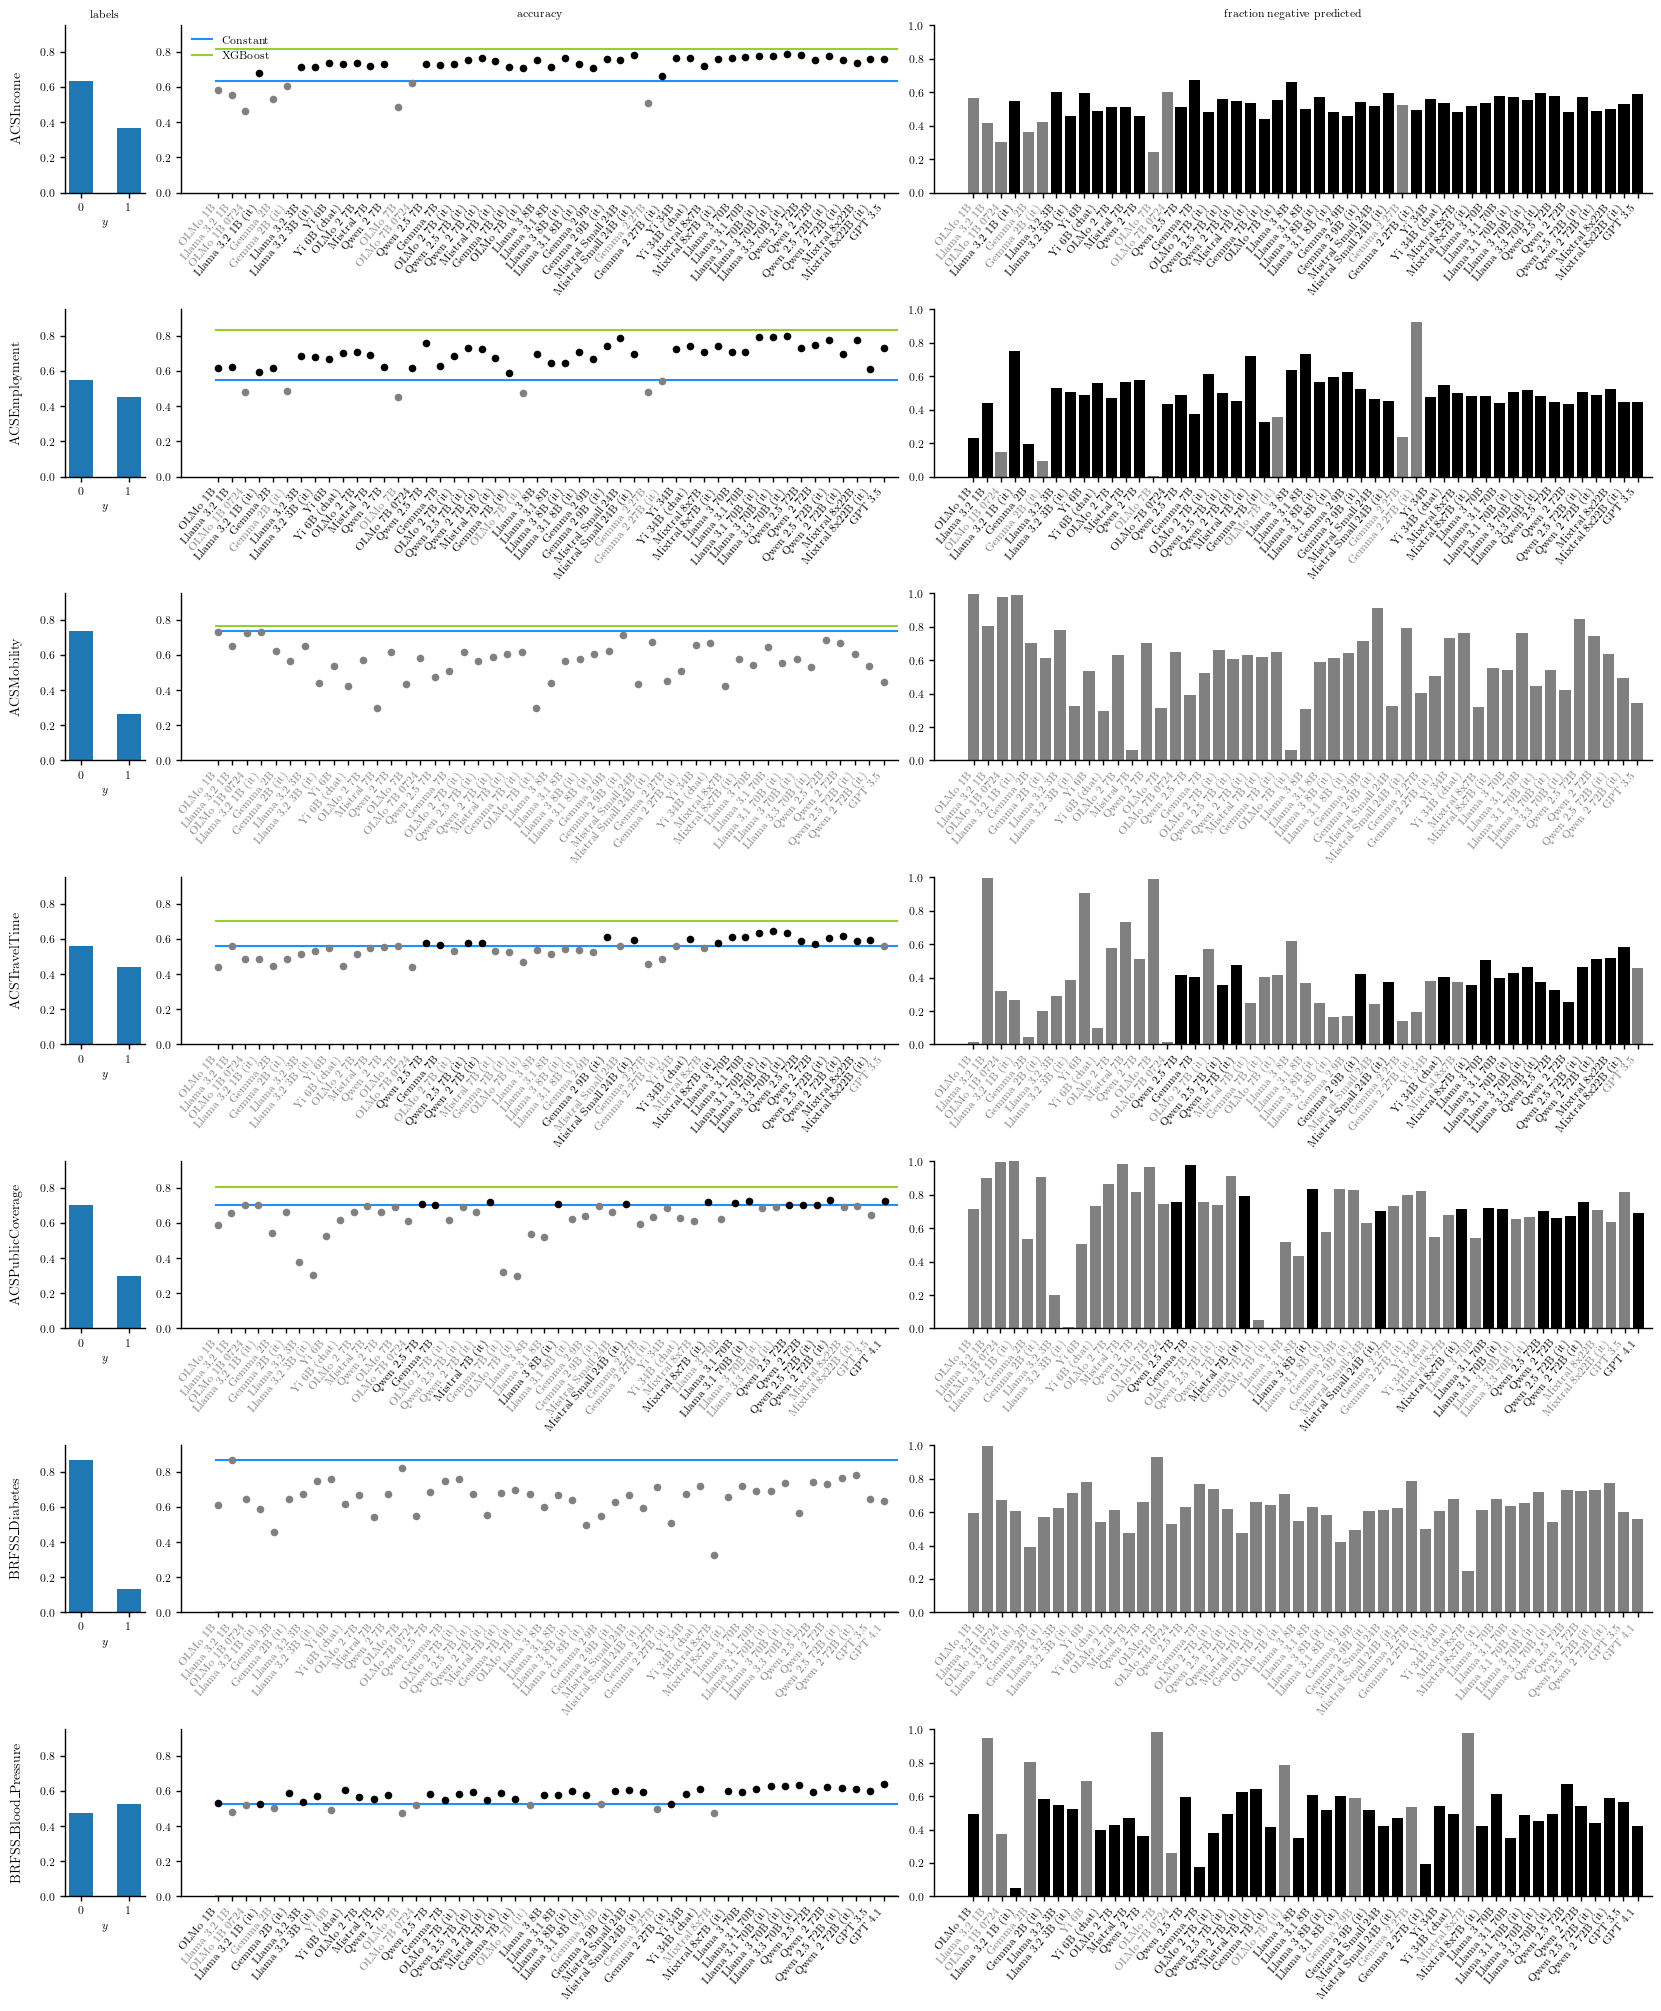

In [ ]:
# one big plot
tasks_to_plot = TASKS

default_width = 3* plt.rcParams['figure.figsize'][0]
custom_height = 20 #plt.rcParams['figure.figsize'][1]

fig, axs = plt.subplots(
    len(tasks_to_plot),
    3,
    figsize=(default_width, custom_height),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1, 9, 9]},
)
axs[0, 0].set_title("labels")
axs[0, 1].set_title("accuracy")
axs[0, 2].set_title("fraction negative predicted")
pad = 5  # pt

for i, task in enumerate(tasks_to_plot):
    print(task)
    axs[i, 0].annotate(
        task.replace("_", " "),
        xy=(0, 0.5),
        xytext=(-axs[i, 0].yaxis.labelpad - pad, 0),
        xycoords=axs[i, 0].yaxis.label,
        textcoords="offset points",
        size="medium",
        ha="right",
        va="center",
        rotation=90,
    )

    # label distribution
    y_true = data[task][1]
    axs[i, 0] = plot_label_dist(axs[i, 0], y_true, ylims=(0, 0.95))

    # model accuracy
    axs[i, 1] = plot_accuracies(
        ax=axs[i, 1],
        task=task,
        evals=evals_per_task,
        baseline_evals=baseline_evals,
        models_above_baseline=models_better_const,
        ylims=(0, 0.95),
        hline_xmin=-0.2,
        hline_xmax=predictions_all[task].shape[1] + 0.1,
    )

    # fraction of negative predicted samples
    axs[i, 2] = plot_neg_predicted(
        axs[i, 2],
        task=task,
        evals=evals_per_task,
        models_above_baseline=models_better_const,
    )

    axs[0, 1].legend()

file_name = "".join(
    [
        f"performance-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
    ]
)

for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_ROOT_DIR / (file_name + ending))
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
plt.show()

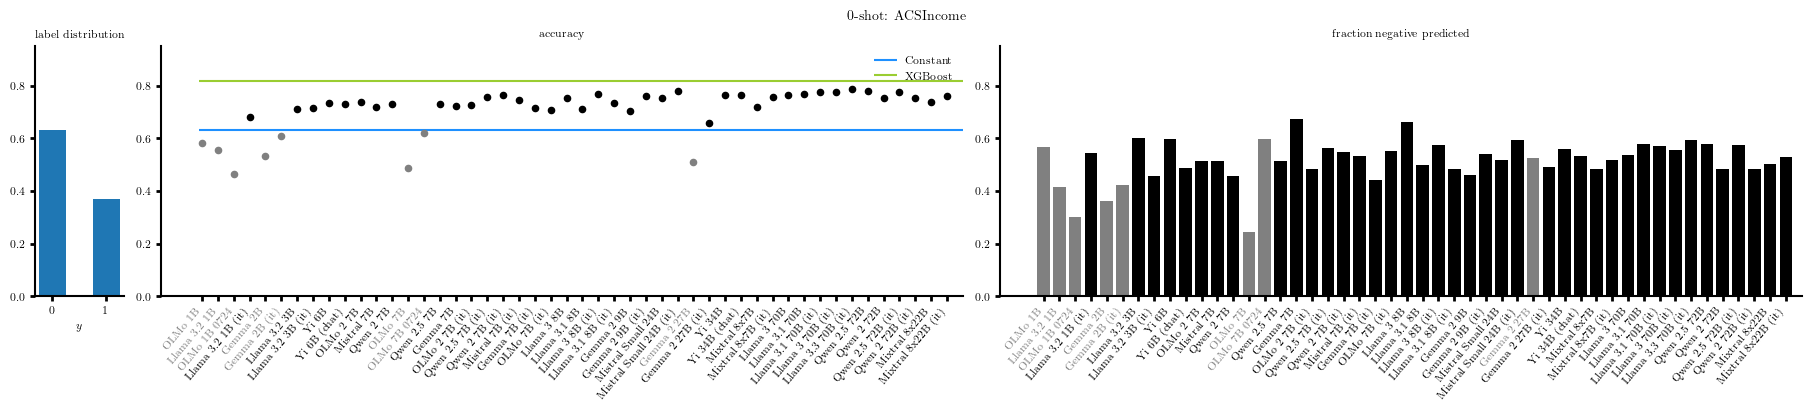

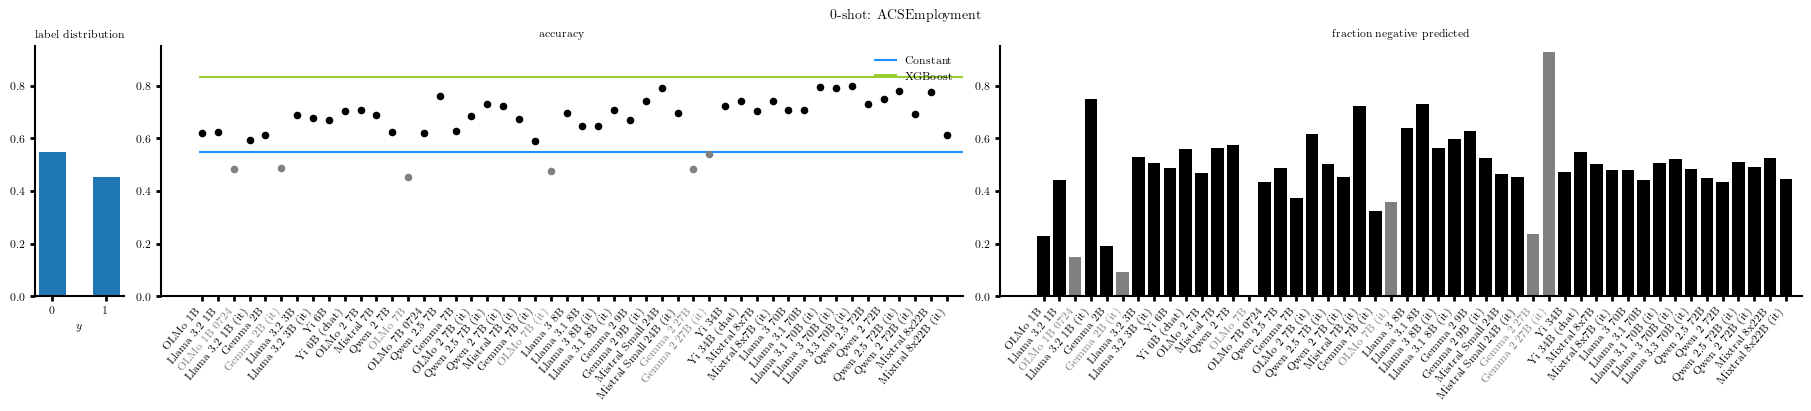

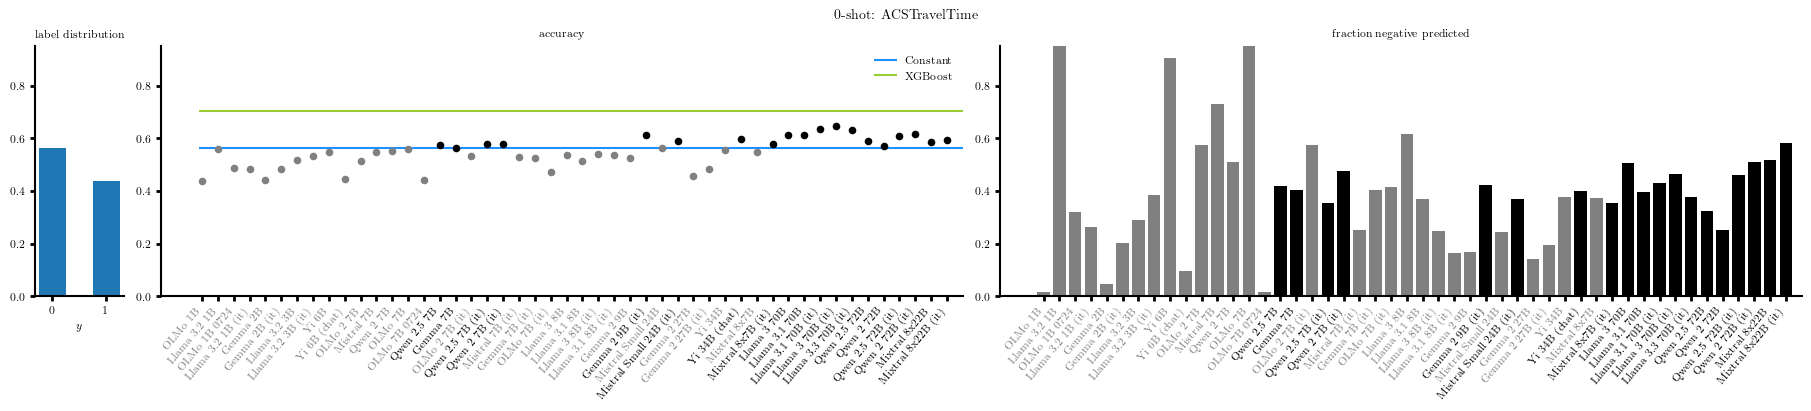

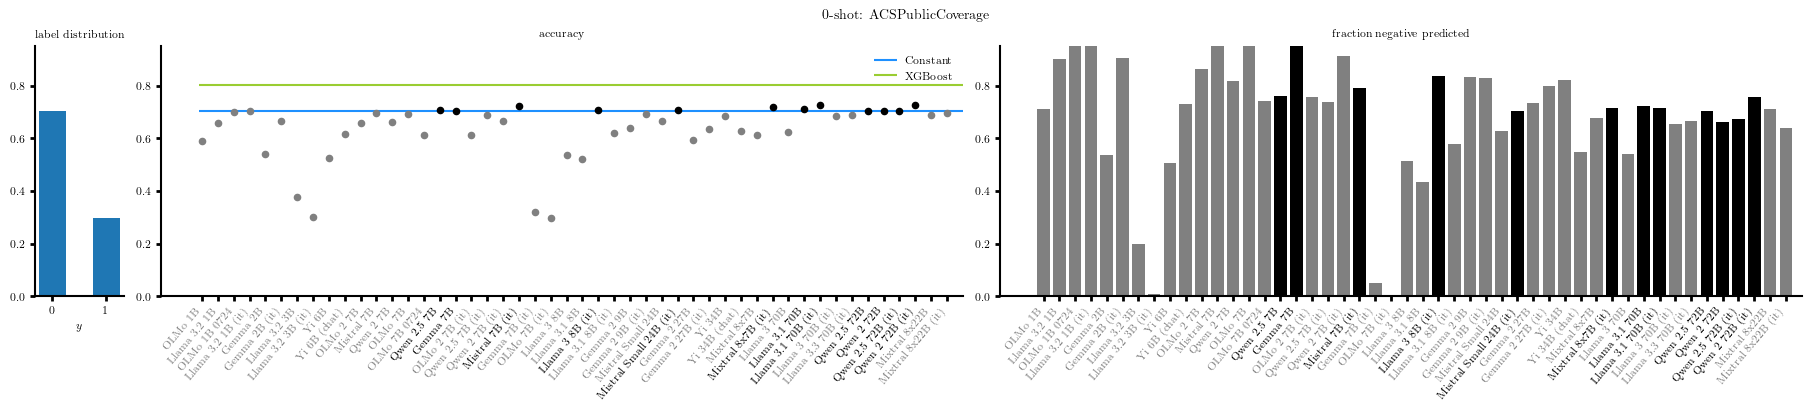

gpt-3.5-turbo-0125
gpt-3.5-turbo-0125


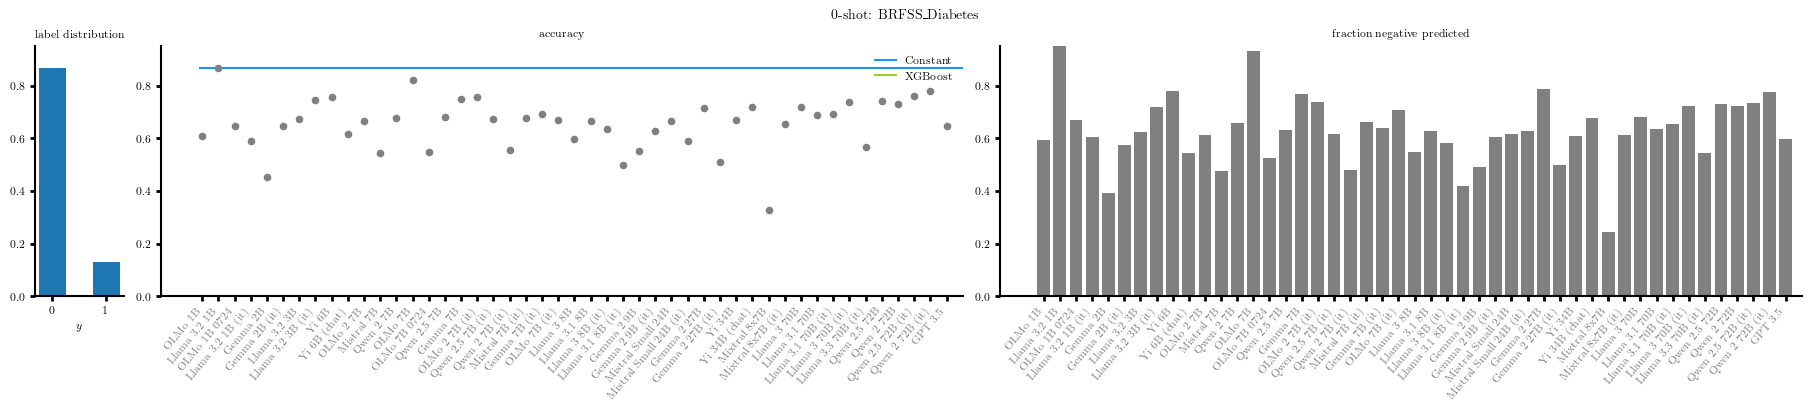

gpt-3.5-turbo-0125
gpt-4.1
gpt-3.5-turbo-0125
gpt-4.1


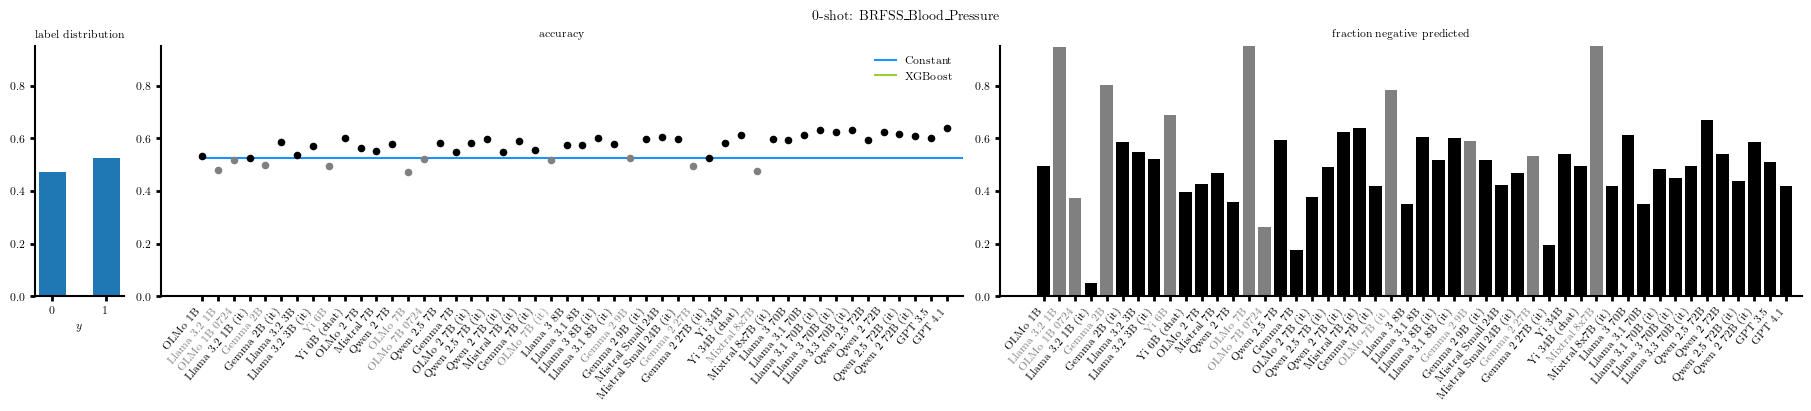

In [12]:
# one plot per task
for task in TASKS:  # , 'ACSEmployment', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure']:
    fig, axs = plt.subplots(
        1,
        3,
        figsize=(18, 4),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1, 9, 9]},
    )
    fig.suptitle(f"{num_shots}-shot: {task}")
    axs[0].set_title("label distribution")
    axs[1].set_title("accuracy")
    axs[2].set_title("fraction negative predicted")
    pad = 5  # pt
    # axs[0].annotate(task, xy=(0, 0.5), xytext=(-axs[0].yaxis.labelpad - pad, 0), xycoords=axs[0].yaxis.label, textcoords='offset points', size='medium', ha='right', va='center')

    ylims = (0, 0.95)
    # label distribution
    labels = data[task][1]
    axs[0] = plot_label_dist(axs[0], labels, ylims=ylims)

    # model accuracy
    # to exclude constant classifiers: evals = evals_non_const
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_per_task,
        baseline_evals=baseline_evals,
        models_above_baseline=models_better_const,
        hline_xmin=-0.2,
        hline_xmax=predictions_all[task].shape[1] + 0.1,
        ylims=ylims,
    )

    # fraction of negative predicted samples
    axs[2] = plot_neg_predicted(
        axs[2],
        task=task,
        evals=evals_per_task,
        models_above_baseline=models_better_const,
        omit_non_highlight_labels=False,
        ylims=ylims,
    )

    # if task == "ACSIncome":
    axs[1].legend()

    file_name = "".join(
        [
            f"performance-{num_shots}-shot",
            f"-{task}",
            "_tresh_fitted" if threshold_fitted == 1 else "",
            "_better_const" if restrict_to_better_const else "",
            "_pos_instances" if restrict_to_positive_label else "",
            "_neg_instances" if restrict_to_negative_label else "",
            ".png",
        ]
    )
    plt.savefig(FIGURES_ROOT_DIR / file_name)
    plt.show()

## top-k models

In [13]:
top_k = 10
topk_models = {}
for task in TASKS:
    df_task = df_same_prompt[df_same_prompt["task"] == task].sort_values(
        by="accuracy", ascending=False
    )
    topk_models[task] = df_task.iloc[:top_k]
topk_models["BRFSS_Blood_Pressure"]

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path,n_samples,fpr,ppr,num_pred_negatives,num_pred_positives,balanced_accuracy
835,BRFSS_Blood_Pressure,gpt-4.1,0,1,1.000000,0.637831,1727077176,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-gpt-4.1/g...,results/tableshift/0-bullet-is/model-gpt-4.1/g...,84676,0.439212,0.580271,35541,49135,0.633947
861,BRFSS_Blood_Pressure,meta-llama--Meta-Llama-3.3-70B-Instruct,1,1,0.060156,0.630368,720134975,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-meta-llam...,results/tableshift/0-bullet-is/model-meta-llam...,84676,0.368895,0.506224,41811,42865,0.630405
825,BRFSS_Blood_Pressure,meta-llama--Meta-Llama-3.1-70B-Instruct,1,1,0.405983,0.629824,1614636830,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-meta-llam...,results/tableshift/0-bullet-is/model-meta-llam...,84676,0.378823,0.515081,41061,43615,0.629388
845,BRFSS_Blood_Pressure,meta-llama--Meta-Llama-3-70B-Instruct,1,1,0.106686,0.625171,1577932570,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-meta-llam...,results/tableshift/0-bullet-is/model-meta-llam...,84676,0.420229,0.549636,38135,46541,0.622882
853,BRFSS_Blood_Pressure,Qwen--Qwen2-72B,0,1,0.407895,0.623790,4230017273,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-Qwen--Qwe...,results/tableshift/0-bullet-is/model-Qwen--Qwe...,84676,0.325543,0.458595,45844,38832,0.626344
823,BRFSS_Blood_Pressure,Qwen--Qwen2.5-72B-Instruct,1,1,0.678571,0.616597,3260916680,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-Qwen--Qwe...,results/tableshift/0-bullet-is/model-Qwen--Qwe...,84676,0.443477,0.563076,36997,47679,0.613568
858,BRFSS_Blood_Pressure,01-ai--Yi-34B-Chat,1,1,0.147609,0.613031,1687436534,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-01-ai--Yi...,results/tableshift/0-bullet-is/model-01-ai--Yi...,84676,0.387703,0.506696,41771,42905,0.612994
840,BRFSS_Blood_Pressure,meta-llama--Meta-Llama-3.1-70B,0,1,0.469799,0.612346,2672189069,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-meta-llam...,results/tableshift/0-bullet-is/model-meta-llam...,84676,0.540160,0.650373,29605,55071,0.604657
829,BRFSS_Blood_Pressure,Qwen--Qwen2-72B-Instruct,1,1,0.731079,0.607811,1472152166,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-Qwen--Qwe...,results/tableshift/0-bullet-is/model-Qwen--Qwe...,84676,0.294612,0.413328,49677,34999,0.612731
822,BRFSS_Blood_Pressure,mistralai--Mistral-Small-24B-Base-2501,0,1,0.561538,0.604977,250203888,0,bullet,is,original,default,results/tableshift/0-bullet-is/model-mistralai...,results/tableshift/0-bullet-is/model-mistralai...,84676,0.470666,0.577200,35801,48875,0.601163


## Plot Risk Scores

In [14]:
models_common = set(risk_scores[TASKS[0]].columns)
for task in TASKS[1:]:
    models_common = models_common.intersection(set(risk_scores[task].columns))

ACSIncome


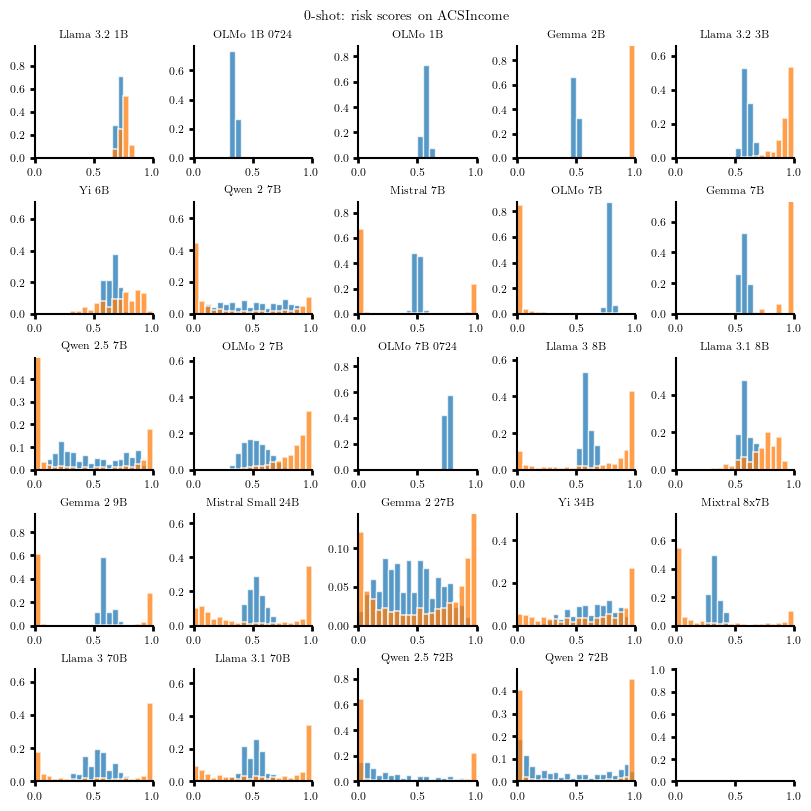

ACSEmployment


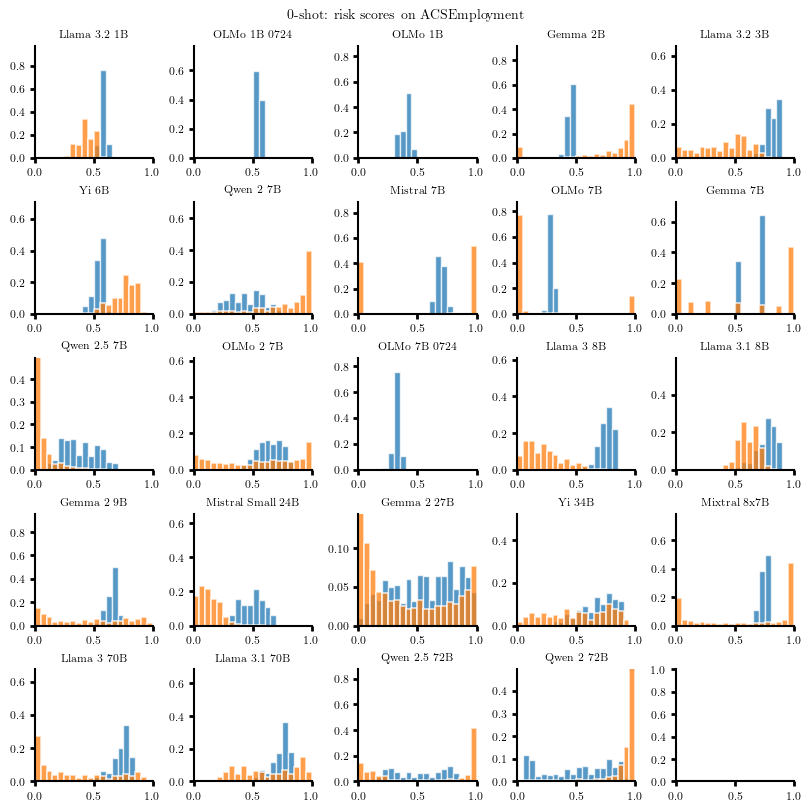

ACSTravelTime


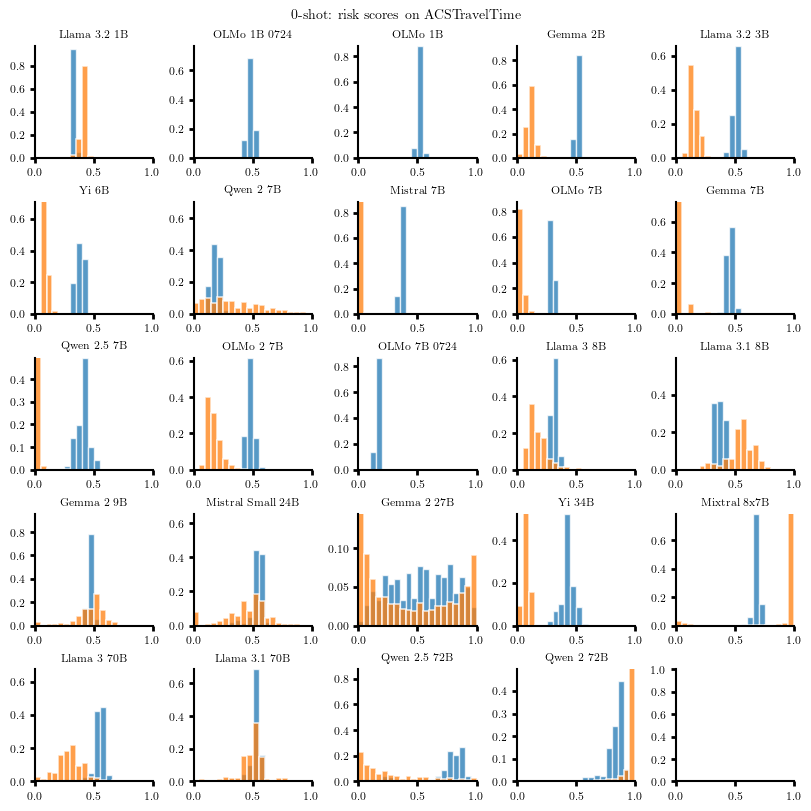

ACSPublicCoverage


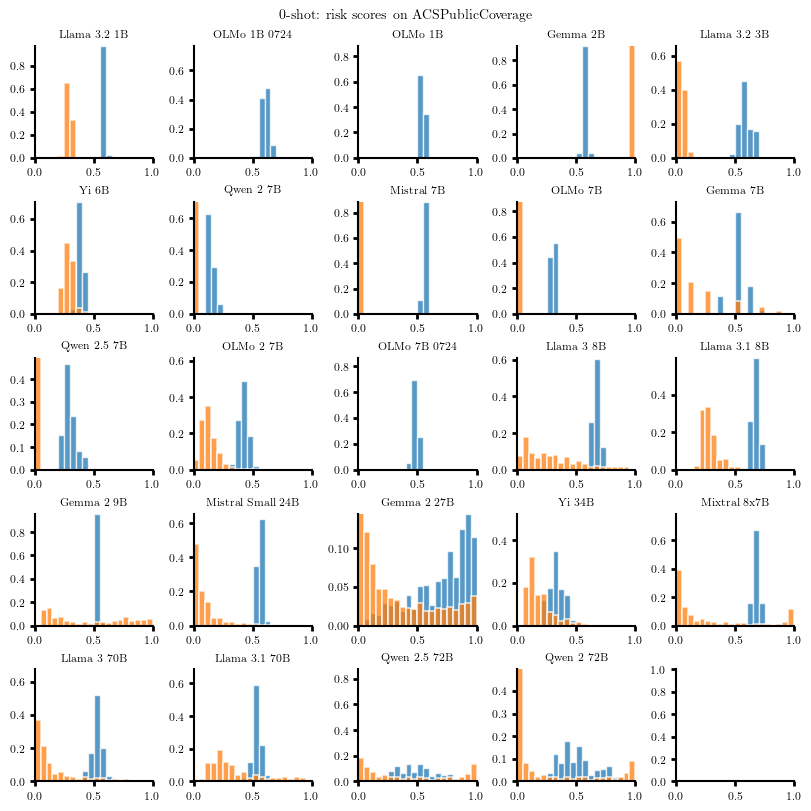

BRFSS_Diabetes


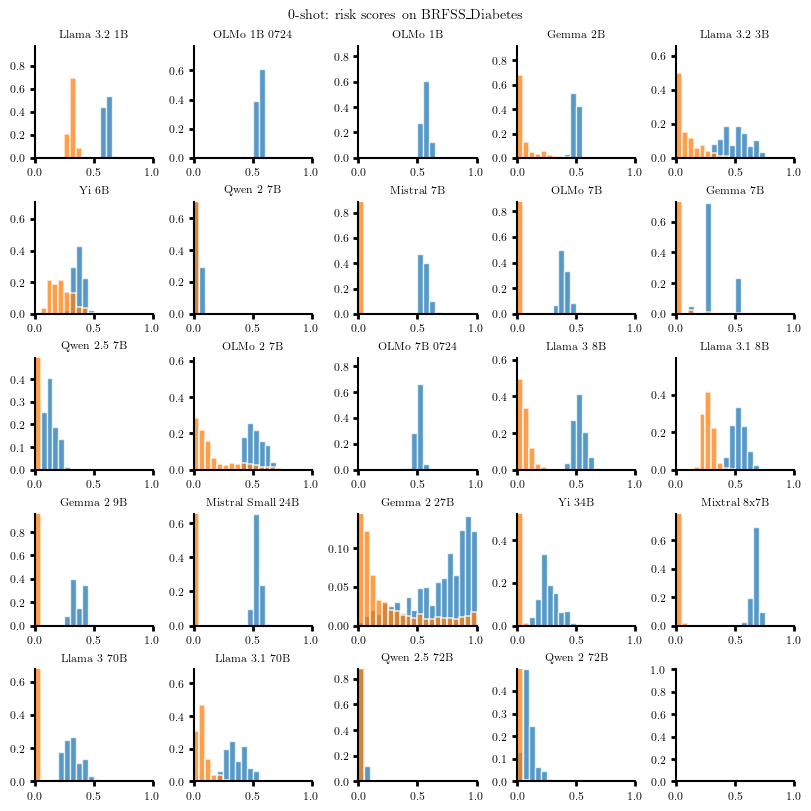

BRFSS_Blood_Pressure


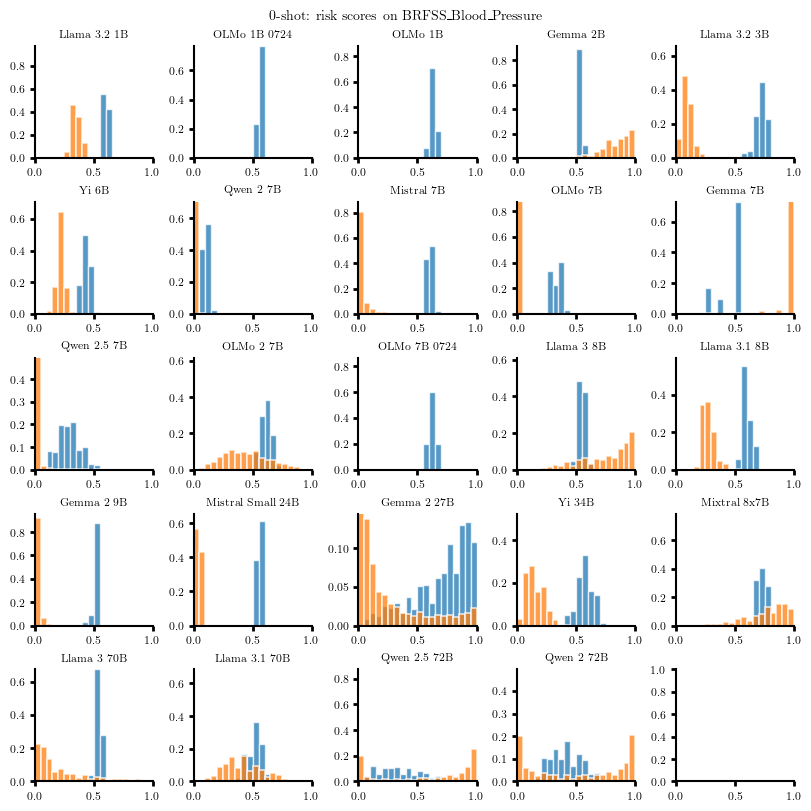

In [15]:
base_models = sorted(
    [model for model in models_common if not is_instruction_tuned(model)],
    key=get_size,
)
it_models = sorted(
    [model for model in models_common if is_instruction_tuned(model)],
    key=get_size,
)
len(base_models), len(it_models)


# to ensure axis are the same across plots, get max y value per model
ymax = {}
for model in base_models:
    ymax[model] = 0
    for task in TASKS:
        N = risk_scores[task].shape[0]
        task_max = max(
            np.histogram(
                risk_scores[task][model],
                weights=np.zeros((N,)) + 1.0 / N,
                bins=np.arange(0, 1.01, 0.05),
            )[0]
        )
        if task_max > ymax[model]:
            ymax[model] = task_max


for task in TASKS:
    print(task)
    N = risk_scores[task].shape[0]
    num_row, num_col = 5, 5
    fig, axs = plt.subplots(num_row, num_col, figsize=(8, 8), constrained_layout=True)
    fig.suptitle(f"{num_shots}-shot: risk scores on {task}")
    for i, model in enumerate(base_models):

        coresponding_it_model = [
            itm
            for itm in it_models
            if prettify_model_name(key_to_model(itm)).startswith(
                prettify_model_name(key_to_model(model))
            )
        ]
        # print(model, coresponding_it_model)

        axs[i // num_col, i % num_col].set_xlim(0.0, 1.0)
        axs[i // num_col, i % num_col].set_title(
            prettify_model_name(key_to_model(model))
        )
        ys, xs, _ = axs[i // num_col, i % num_col].hist(
            risk_scores[task][model],
            weights=np.zeros((N,)) + 1.0 / N,
            alpha=0.75,
            label="base",
            bins=np.arange(0, 1.01, 0.05),
            edgecolor="w",
            linewidth=1,
        )
        axs[i // num_col, i % num_col].set_ylim(0.0, ymax[model])
        if len(coresponding_it_model) == 1:
            axs[i // num_col, i % num_col].hist(
                risk_scores[task][coresponding_it_model[0]],
                weights=np.zeros((N,)) + 1.0 / N,
                alpha=0.75,
                label="it",
                bins=np.arange(0, 1.01, 0.05),
                edgecolor="w",
                linewidth=1.2,
            )
    axs[-1, -1].legend()

    file_name = "".join(
        [
            f"risk-scores-{num_shots}-shot",
            f"-{task}",
            "_tresh_fitted" if threshold_fitted == 1 else "",
            "_better_const" if restrict_to_better_const else "",
            "_pos_instances" if restrict_to_positive_label else "",
            "_neg_instances" if restrict_to_negative_label else "",
            ".png",
        ]
    )
    plt.savefig(FIGURES_ROOT_DIR / file_name)
    plt.show()

## Fitted Threshold vs. not fitted

In [16]:
num_shots = 0
df_fitted = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == 1)
]
df_not_fitted = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == 0)
]

print(set(df_not_fitted["model"].unique()) == set(df_fitted["model"].unique()))

predictions_fitted = load_model_outputs_same_prompt(
    df_fitted, tasks=TASKS, return_risk_scores=False
)
predictions_not_fitted = load_model_outputs_same_prompt(
    df_not_fitted, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_fitted[metric] = (
        df_fitted["eval_results_path"].apply(partial(get_metric, metric=metric)).copy()
    )
    df_not_fitted[metric] = (
        df_not_fitted["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task_fitted = {}  # [task][metric][model]
evals_per_task_not_fitted = {}  # [task][metric][model]
for task in df_fitted["task"].unique():
    df_task = df_fitted[df_fitted["task"] == task]
    evals_per_task_fitted[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }
for task in df_not_fitted["task"].unique():
    df_task = df_not_fitted[df_not_fitted["task"] == task]
    evals_per_task_not_fitted[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

False
gpt-3.5-turbo-0125
gpt-3.5-turbo-0125
gpt-4.1


/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_50513/2072682379.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fitted[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_50513/2072682379.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_not_fitted[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_50513/2072682379.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

In [17]:
models_better_const_fitted = {
    task: [
        m
        for m in predictions_fitted[task].columns
        if df_fitted[(df_fitted["task"] == task) & (df_fitted["model"] == m)][
            "accuracy"
        ].item()
        > baseline_evals[task]["Constant"]["accuracy"]
    ]
    for task in predictions_fitted.keys()
}

models_better_const_not_fitted = {
    task: [
        m
        for m in predictions_not_fitted[task].columns
        if df_not_fitted[
            (df_not_fitted["task"] == task) & (df_not_fitted["model"] == m)
        ]["accuracy"].item()
        > baseline_evals[task]["Constant"]["accuracy"]
    ]
    for task in predictions_not_fitted.keys()
}

performance-fitted-vs-unfitted-0-shot-ACSEmployment.png


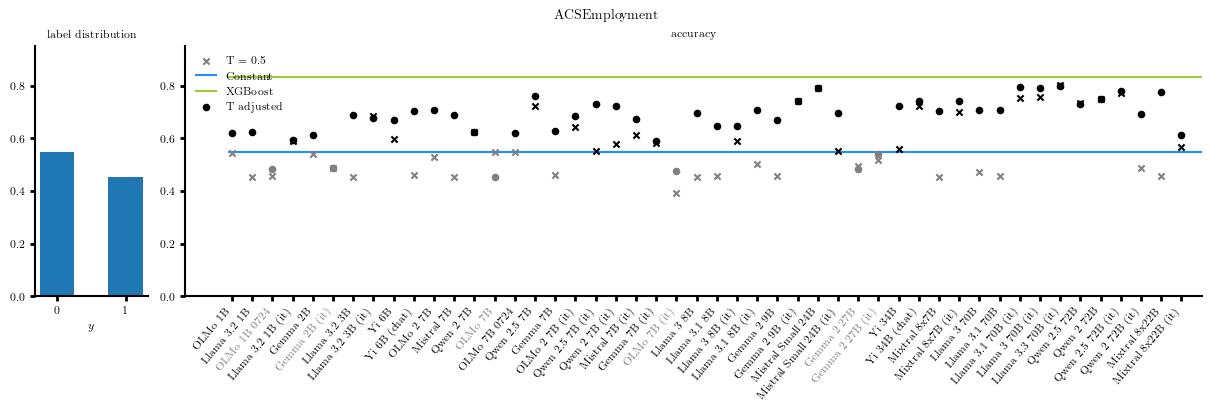

performance-fitted-vs-unfitted-0-shot-ACSPublicCoverage.png


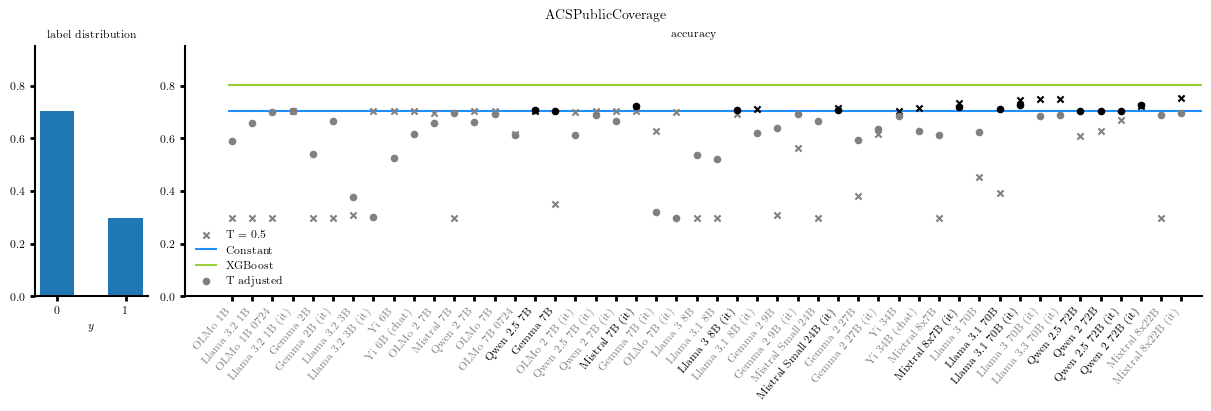

performance-fitted-vs-unfitted-0-shot-ACSIncome.png


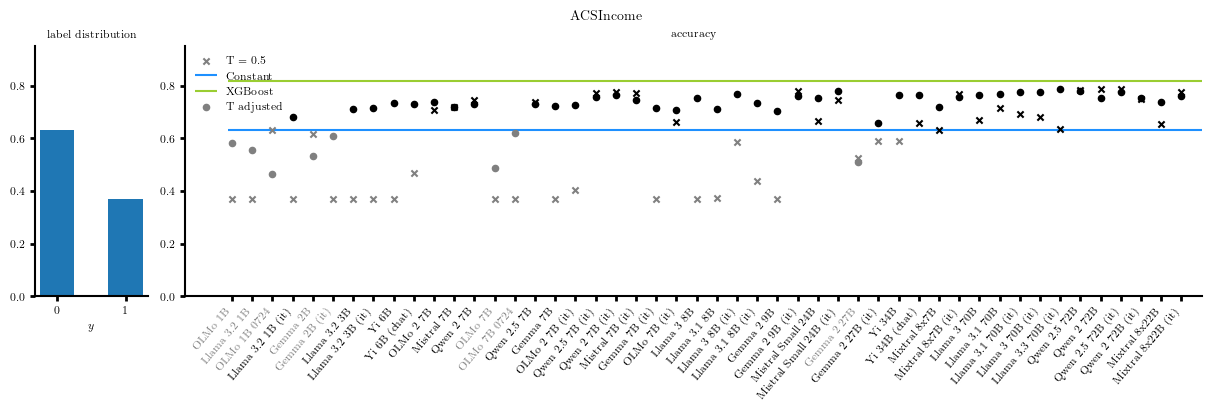

performance-fitted-vs-unfitted-0-shot-ACSTravelTime.png


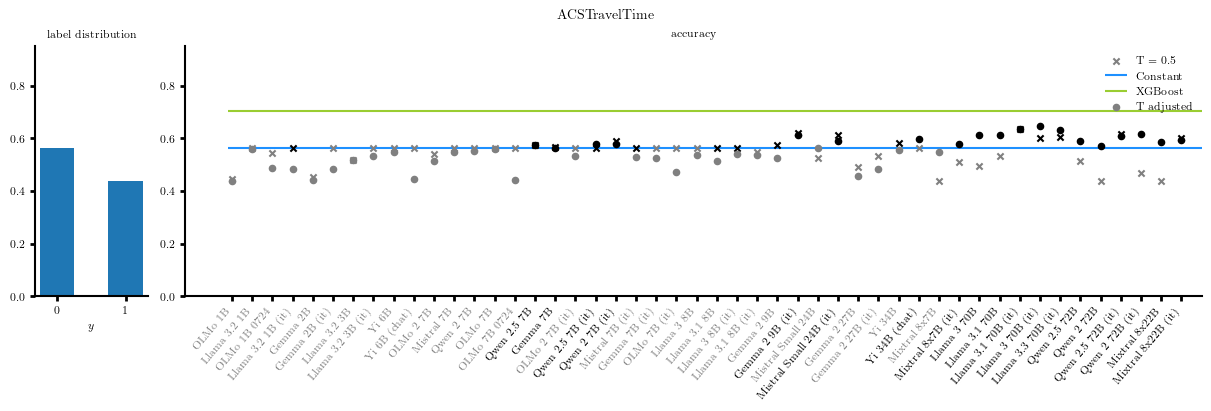

In [18]:
# one plot per task
for i, task in enumerate(set(predictions_fitted.keys()).intersection(set(predictions_not_fitted.keys()))):
    fig, axs = plt.subplots(
        1,
        2,
        figsize=(12, 4),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1, 9]},
    )

    fig.suptitle(task)
    axs[0].set_title("label distribution")
    axs[1].set_title("accuracy")
    pad = 5

    ylims = (0, 0.95)

    # label distribution
    labels = data[task][1]
    axs[0] = plot_label_dist(axs[0], labels, ylims=ylims)

    # model accuracy
    # to exclude constant classifiers: evals = evals_non_const
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_per_task_not_fitted,
        baseline_evals=None,
        models_above_baseline=models_better_const_not_fitted,
        ylims=ylims,
        marker="x",
        scatter_label="T = 0.5",
    )
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_per_task_fitted,
        baseline_evals=baseline_evals,
        models_above_baseline=models_better_const_fitted,
        hline_xmin=-0.2,
        hline_xmax=predictions_fitted[task].shape[1] + 0.1,
        ylims=ylims,
        marker="o",
        scatter_label="T adjusted",
    )

    # if task == "ACSIncome":
    # labels, handles = axs[1].get_legend_handles_labels()
    # sorted_handles_labels = sorted(zip(handles, labels), key=lambda item: item[0], reverse=True)
    # handles, labels = zip(*sorted_handles_labels)
    # axs[1].legend(handles, labels)

    axs[1].legend()
    file_name = "".join(
        [
            f"performance-fitted-vs-unfitted-{num_shots}-shot",
            f"-{task}",
            "_better_const" if restrict_to_better_const else "",
            "_pos_instances" if restrict_to_positive_label else "",
            "_neg_instances" if restrict_to_negative_label else "",
            ".png",
        ]
    )
    plt.savefig(FIGURES_ROOT_DIR / file_name)
    print(file_name)
    plt.show()

## 0-shot vs 10-shot

In [19]:
df = pd.read_csv(results_df_path)

df_0shot = df[
    (df["num_shots"] == 0)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == 1)
]
df_10shot = df[
    (df["num_shots"] == 10)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == 1)
]

common_tasks = set(df_10shot["task"].unique()).intersection(
    set(df_0shot["task"].unique()).intersection(TASKS)
)
df_0shot = df_0shot[df_0shot["task"].apply(lambda t: t in common_tasks)]
df_10shot = df_10shot[df_10shot["task"].apply(lambda t: t in common_tasks)]

print(set(df_10shot["model"].unique()) == set(df_0shot["model"].unique()))

predictions_0shot = load_model_outputs_same_prompt(
    df_0shot, tasks=common_tasks, return_risk_scores=False
)
predictions_10shot = load_model_outputs_same_prompt(
    df_10shot, tasks=common_tasks, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_0shot[metric] = (
        df_0shot["eval_results_path"].apply(partial(get_metric, metric=metric)).copy()
    )
    df_10shot[metric] = (
        df_10shot["eval_results_path"].apply(partial(get_metric, metric=metric)).copy()
    )

evals_per_task_0shot = {}  # [task][metric][model]
evals_per_task_10shot = {}  # [task][metric][model]
for task in df_0shot["task"].unique():
    df_task = df_0shot[df_0shot["task"] == task]
    evals_per_task_0shot[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }
for task in df_10shot["task"].unique():
    df_task = df_10shot[df_10shot["task"] == task]
    evals_per_task_10shot[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

False
gpt-3.5-turbo-0125
gpt-4.1
gpt-3.5-turbo-0125


In [20]:
models_better_const_0shot = {
    task: [
        m
        for m in predictions_0shot[task].columns
        if df_0shot[(df_0shot["task"] == task) & (df_0shot["model"] == m)][
            "accuracy"
        ].item()
        > baseline_evals[task]["Constant"]["accuracy"]
    ]
    for task in common_tasks
}

models_better_const_10shot = {
    task: [
        m
        for m in predictions_10shot[task].columns
        if df_10shot[(df_10shot["task"] == task) & (df_10shot["model"] == m)][
            "accuracy"
        ].item()
        > baseline_evals[task]["Constant"]["accuracy"]
    ]
    for task in common_tasks
}

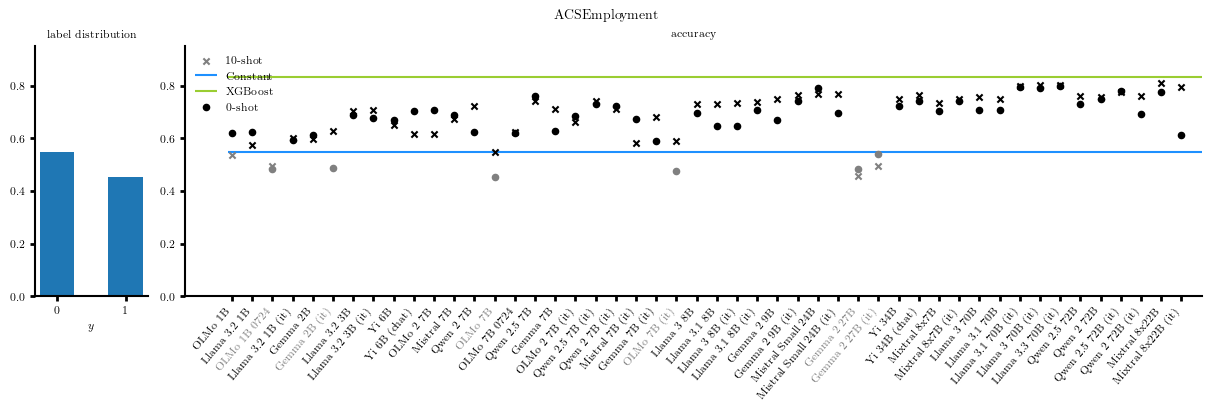

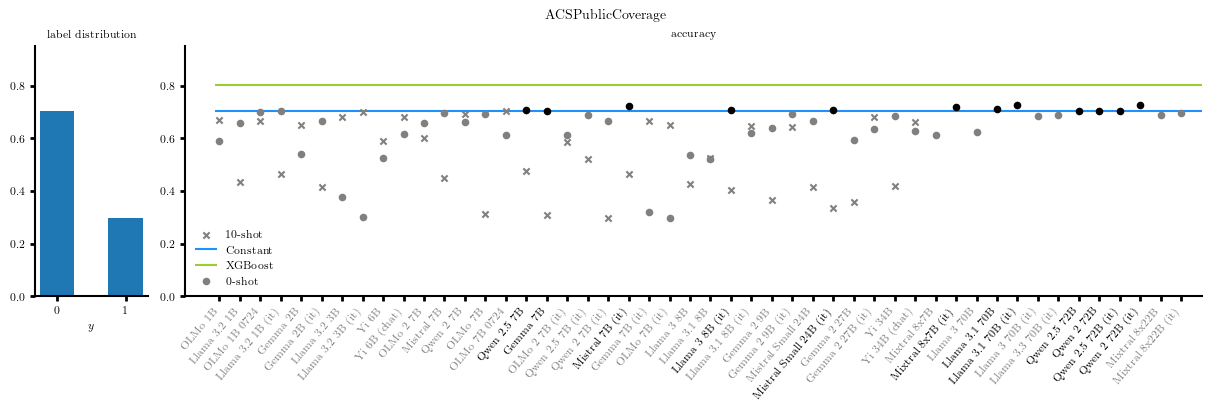

gpt-3.5-turbo-0125
gpt-4.1


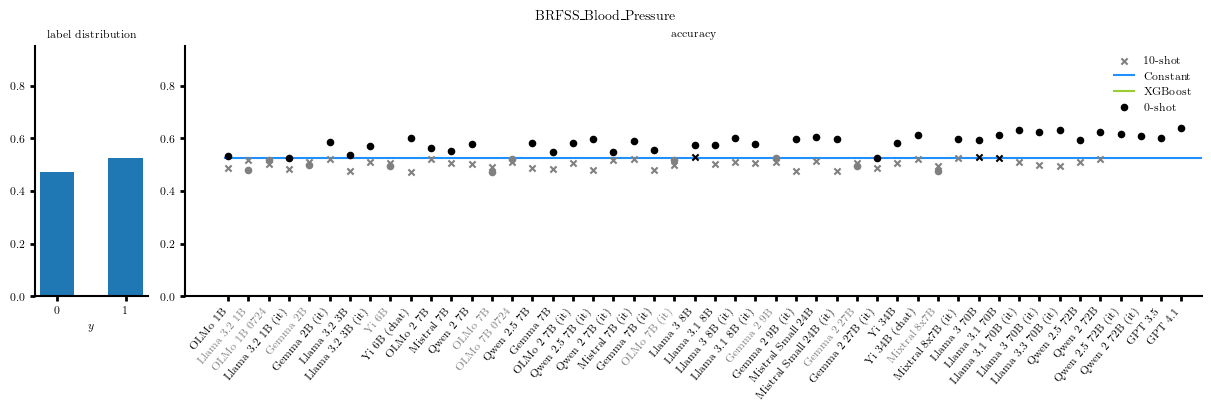

gpt-3.5-turbo-0125


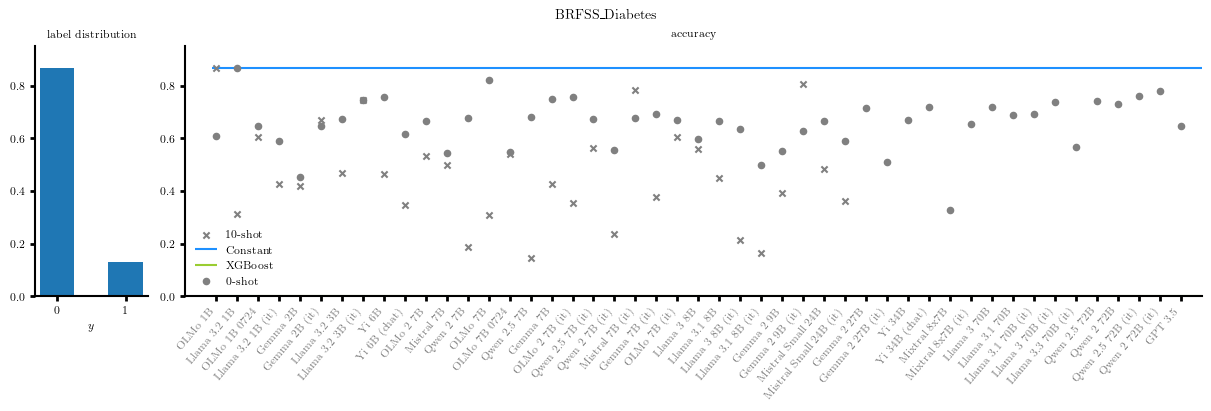

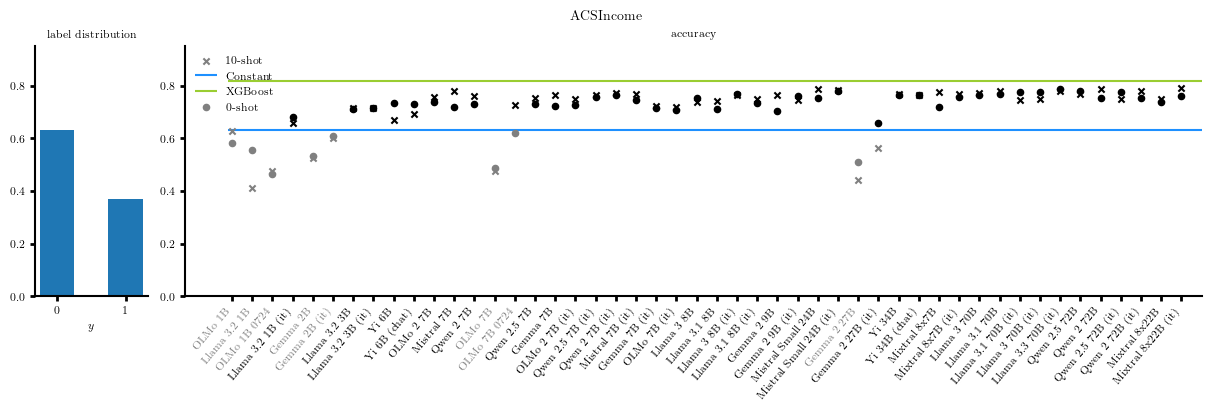

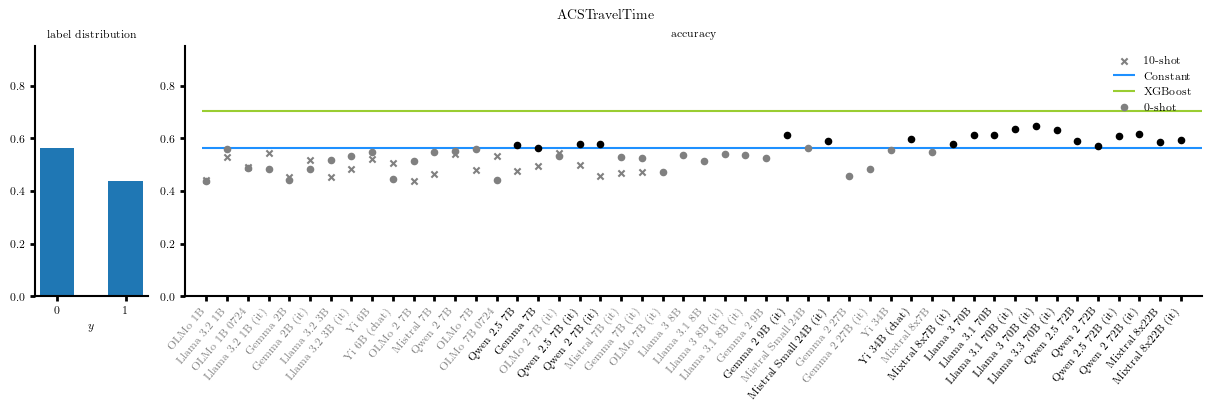

In [21]:
# one plot per task
for i, task in enumerate(common_tasks):
    fig, axs = plt.subplots(
        1,
        2,
        figsize=(12, 4),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1, 9]},
    )

    fig.suptitle(task)
    axs[0].set_title("label distribution")
    axs[1].set_title("accuracy")
    pad = 5

    ylims = (0, 0.95)

    # label distribution
    labels = data[task][1]
    axs[0] = plot_label_dist(axs[0], labels, ylims=ylims)

    # model accuracy
    # to exclude constant classifiers: evals = evals_non_const
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_per_task_10shot,
        baseline_evals=None,
        models_above_baseline=models_better_const_10shot,
        ylims=ylims,
        marker="x",
        scatter_label="10-shot",
    )
    axs[1] = plot_accuracies(
        ax=axs[1],
        task=task,
        evals=evals_per_task_0shot,
        baseline_evals=baseline_evals,
        models_above_baseline=models_better_const_0shot,
        hline_xmin=-0.2,
        hline_xmax=predictions_0shot[task].shape[1] + 0.1,
        ylims=ylims,
        marker="o",
        scatter_label="0-shot",
    )

    # if task == "ACSIncome":
    # labels, handles = axs[1].get_legend_handles_labels()
    # sorted_handles_labels = sorted(zip(handles, labels), key=lambda item: item[0], reverse=True)
    # handles, labels = zip(*sorted_handles_labels)
    # axs[1].legend(handles, labels)

    axs[1].legend()
    file_name = "".join(
        [
            f"performance-0-vs-10-shot",
            f"-{task}",
            "_tresh_fitted" if threshold_fitted == 1 else "",
            "_better_const" if restrict_to_better_const else "",
            "_pos_instances" if restrict_to_positive_label else "",
            "_neg_instances" if restrict_to_negative_label else "",
            ".png",
        ]
    )
    plt.savefig(FIGURES_ROOT_DIR / file_name)
    plt.show()

In [22]:
np.array(
    [
        val
        for (model, val) in evals_per_task_0shot["ACSIncome"]["accuracy"].items()
        if model in models_better_const_0shot["ACSIncome"]
    ]
).mean()

0.7418760889155903

In [23]:
np.array(
    [
        val
        for (model, val) in evals_per_task_10shot["ACSIncome"]["accuracy"].items()
        if model in models_better_const_10shot["ACSIncome"]
    ]
).mean()

0.7517748573145088